In [31]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [32]:
df = pd.read_csv("../data/Student Social Media And Mental Health Impact.csv")

In [33]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [34]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (5000, 13)

Column Names:
['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level', 'Mental_Health_Score']

Missing Values:
Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

Duplicated Rows: 2

Data Types:
Age                          int64
Gender                         str
Country                        str
Academic_Level                 str
Most_Used_Platform             str
Purpose_Of_Use                 str
Avg_Daily_Usage_Hours      float64
Daily_Unlocks                int64
Stud

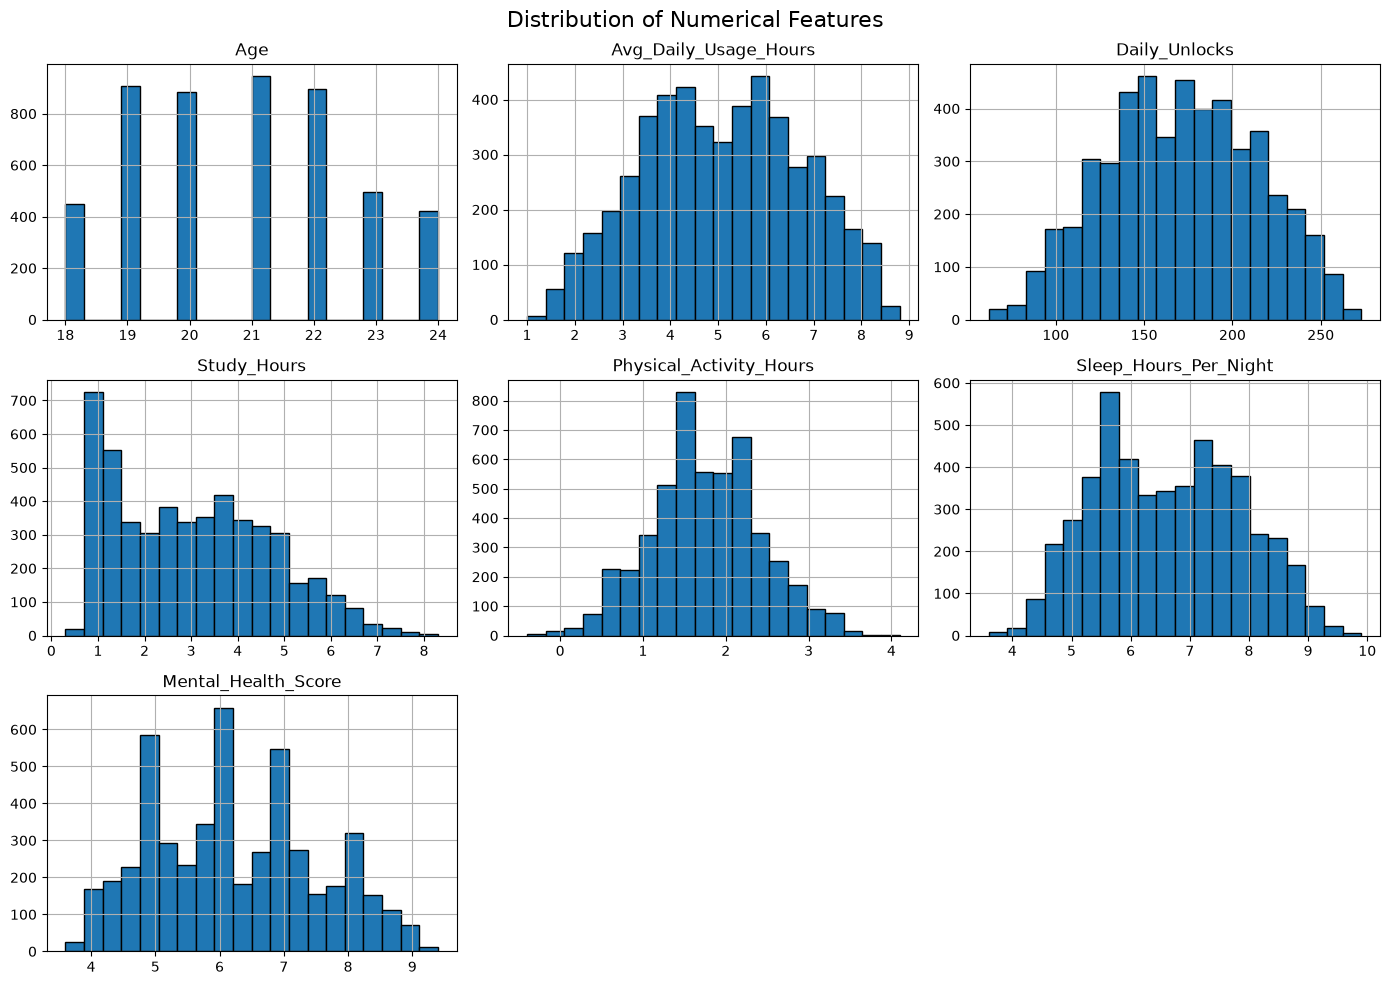

In [35]:
# =========================================================
# 3. EDA - HISTOGRAMS
# =========================================================

numeric_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Study_Hours",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score"
]

df[numeric_cols].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [36]:
# =========================================================
# 4. OUTLIER CHECK USING Z-SCORE
# =========================================================

outlier_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night"
]

z_scores = np.abs(
    stats.zscore(
        df[outlier_cols],
        nan_policy="omit"
    )
)

outlier_mask = (z_scores > 3).any(axis=1)

print("Original rows:", len(df))
print("Potential outlier rows:", outlier_mask.sum())
print("Percentage:", round(outlier_mask.mean() * 100, 2), "%")

Original rows: 5000
Potential outlier rows: 0
Percentage: 0.0 %


In [37]:
# ============================================================
# 5. CREATE MENTAL HEALTH CATEGORY
# ============================================================

bins = [0, 4, 7, 10]
labels = ["Poor", "Fair", "Good"]

df["Mental_Health_Category"] = pd.cut(
    df["Mental_Health_Score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Remove rows if score does not fall into our defined range
df = df.dropna(subset=["Mental_Health_Category"])

print(df["Mental_Health_Category"].value_counts())

Mental_Health_Category
Fair    3610
Good    1273
Poor     117
Name: count, dtype: int64


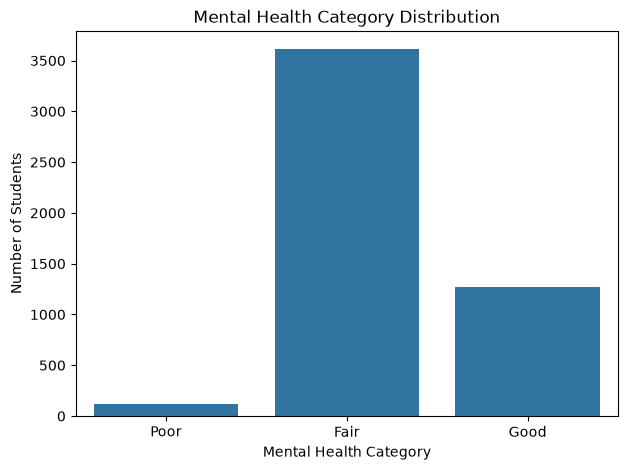

Mental_Health_Category
Fair    72.20
Good    25.46
Poor     2.34
Name: proportion, dtype: float64


In [38]:
# ============================================================
# 6. CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Mental_Health_Category"
)

plt.title("Mental Health Category Distribution")
plt.xlabel("Mental Health Category")
plt.ylabel("Number of Students")
plt.show()

print(
    df["Mental_Health_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Stress_Level             High    Low  Medium  Very High
Mental_Health_Category                                 
Poor                     6.84   0.00    0.00      93.16
Fair                    37.17   2.58   18.42      41.83
Good                     7.07  43.28   49.49       0.16


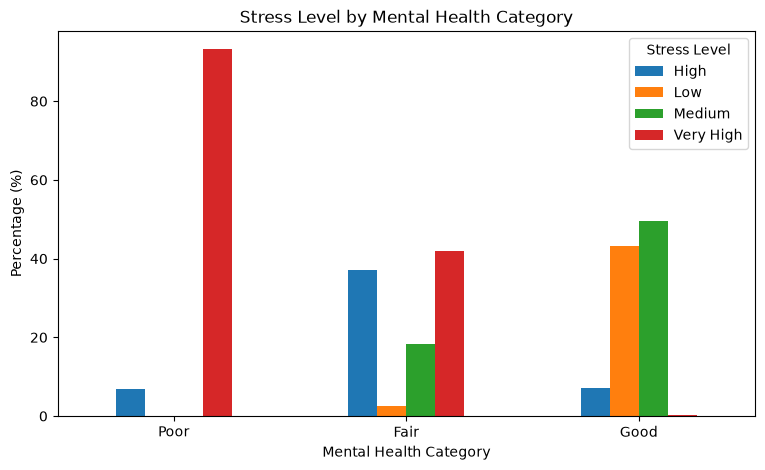

In [39]:
# ============================================================
# STRESS LEVEL VS MENTAL HEALTH
# ============================================================

stress_table = pd.crosstab(
    df["Mental_Health_Category"],
    df["Stress_Level"],
    normalize="index"
) * 100

print(stress_table.round(2))

stress_table.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Stress Level by Mental Health Category")
plt.xlabel("Mental Health Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Stress Level")
plt.show()

In [40]:
# =========================================================
# 11. PREPARE FEATURES AND TARGET
# =========================================================

y_raw = df["Mental_Health_Category"]

# Encode target
le = LabelEncoder()

y = le.fit_transform(y_raw)

print("Target mapping:")

for i, label in enumerate(le.classes_):
    print(i, "=", label)

Target mapping:
0 = Fair
1 = Good
2 = Poor


In [41]:
# =========================================================
# 12. CREATE FEATURE DATA
# =========================================================

X_raw = df.drop(
    columns=[
        "Mental_Health_Score",
        "Mental_Health_Category",
        "Stress_Level"
    ],
    errors="ignore"
)

# One-hot encode categorical variables
X = pd.get_dummies(
    X_raw,
    drop_first=True
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 133)
y shape: (5000,)


In [42]:
# =========================================================
# 13. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(
    pd.Series(y_train).value_counts()
)

print("\nTesting class distribution:")
print(
    pd.Series(y_test).value_counts()
)

Training samples: 4000
Testing samples: 1000

Training class distribution:
0    2888
1    1018
2      94
Name: count, dtype: int64

Testing class distribution:
0    722
1    255
2     23
Name: count, dtype: int64


In [43]:
# =========================================================
# 14. SAVE PROCESSED DATA
# =========================================================

X_train.to_csv(
    "../results/X_train.csv",
    index=False
)

X_test.to_csv(
    "../results/X_test.csv",
    index=False
)

pd.Series(y_train).to_csv(
    "../results/y_train.csv",
    index=False,
    header=["target"]
)

pd.Series(y_test).to_csv(
    "../results/y_test.csv",
    index=False,
    header=["target"]
)

print("Processed data saved successfully!")

Processed data saved successfully!
